# Isotropic–Nematic Phase Transition in Liquid Crystals

Some materials consisting of strongly anisotropic colloids or molecules behave as liquid crystals. Liquid crystals possess many of the mechanical properties of a liquid, such as high fluidity, but are similar to crystals in other physical properties. For example, they may be birefringent and may have anisotropic magnetic or electric susceptibilities.

Liquid crystals often exhibit a transition between the crystalline phase and the isotropic liquid phase as a function of the temperature or the concentration. In this exercise, we will study a temperature-induced phase transition.

Consider a two-dimensional square grid of anisotropic molecules, each characterized by a unit vector $\mathbf{u}$. The molecules $i$ and $j$ interact via the potential

$$
U(r, \mathbf{u}^{(i)}, \mathbf{u}^{(j)}) = -\varepsilon(r)\, \big(\mathbf{u}^{(i)} \cdot \mathbf{u}^{(j)}\big)^2.
$$

The function $\varepsilon(r)$ depends on the distance $r$ between the molecules. We do not consider the fluidity of the system, keeping the molecule positions fixed instead.


## 1. Monte Carlo Sampling

### (a)

Generate a $10 \times 10$ grid of unit vectors and write a script that selects a molecule and rotates its unit vector over an arbitrary angle $0 < \phi < 2\pi$.

Does this transition satisfy detailed balance?

In [55]:
#1a 
import numpy as np
import matplotlib.pyplot as plt
N = 10
#create random angles
theta = 2*np.pi*np.random.rand(N,N)
#unitvectors
u_x = np.cos(theta)
u_y = np.sin(theta)



Zusätzlich Vectorfeld Ploten

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


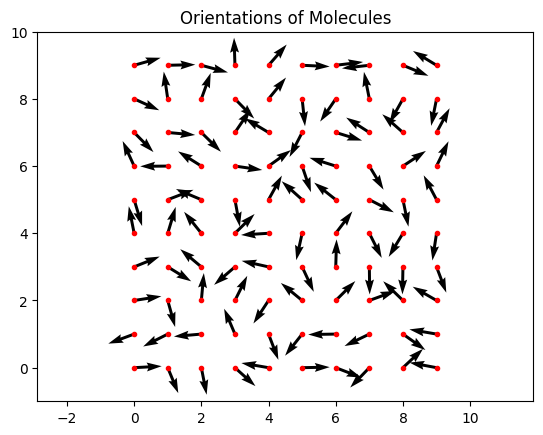

In [56]:
# GridPoints
X, Y = np.meshgrid(np.arange(N), np.arange(N))

# PlotVectorfield
plt.figure()
plt.quiver(X, Y, u_x, u_y)
plt.plot(X,Y,'r.')
plt.title("Orientations of Molecules")
plt.axis("equal")
plt.xlim(-1, N)
plt.ylim(-1, N)
plt.show()

### (b)

Write a Monte Carlo script that simulates a $10 \times 10$ grid of freely rotating molecules interacting only with their nearest neighbours via the potential of Eq. (1).

That means that each molecule only interacts with the four molecules on the adjacent grid points in the two perpendicular directions of the square grid. In terms of the interaction potential of Eq. (1), the function $\varepsilon(r)$ is a step function, equal to $\varepsilon$ for nearest neighbours and zero otherwise.

Use periodic boundary conditions.

In [57]:
#1b Functions
#This function is not needet for the vectorized option
def E_pot_two_particles(theta1,theta2,eps=1.0):
    return -eps*np.cos(theta1-theta2)**2

#Calc whole energy of the System (loop variant)
def calc_E_tot_l(theta, eps=1.0):
    N = theta.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            # right neighbour
            E += E_pot_two_particles(theta[i, j], theta[i, (j + 1) % N], eps)

            # down neighbour
            E += E_pot_two_particles(theta[i, j], theta[(i + 1) % N, j], eps)

    return E

#Calc whole energy of the System (vectorized variant)
def calc_E_tot_v(theta, eps=1.0):
    # use only right neigbours and neigbours below
    right = np.roll(theta,-1,axis=1)
    below = np.roll(theta,-1,axis=0)
    E = -eps*np.sum(np.cos(theta-right)**2 + np.cos(theta-below)**2)
    return E


#Calc the local energy with respect to the four neigbours
def calc_E_loc(theta, i, j, eps= 1.0):
    N = theta.shape[0]
    theta_loc = theta[i,j] #vector for later calculations

    # get the neigbors -> for periodic boundary conditions use Modulo 
    neighbours = np.array([theta[(i+1)%N,j],theta[(i-1)%N,j],
                           theta[i,(j+1)%N],theta[i,(j-1)%N]])

    # summ of the 4 potential energys
    return np.sum(-eps*(np.cos(theta_loc - neighbours))**2)



In [58]:
#test feld
#Lecture Script: 1.3.9
#1st step -> choose any starting configuration
#test = np.arange(1,N**2 + 1).reshape(N,N)
#print(test)
#test2 = np.roll(test,-1,axis=0)
#print(test2)
#compar the two endergy calculation
E_vec = calc_E_tot_v(theta,1.0)
E_loop = calc_E_tot_l(theta,1.0)
print("E vectorisiert berechnet = ",E_vec)
print("E with loop berechnet = ", E_loop)

E vectorisiert berechnet =  -105.34395191831165
E with loop berechnet =  -105.34395191831172


In [59]:
#1b Montecarlo
N_steps = 1000
T = 0.001
for step in range(N_steps):
    #chose random index
    i = np.random.randint(0,N)
    j = np.random.randint(0,N)
    #remember old theta
    theta_old = theta[i,j]
    #random rotation
    theta_new = np.random.rand()*2*np.pi 
    #calca old local energy
    E_loc_old = calc_E_loc(theta,i,j, eps= 1.0)
    #calc new local energy 
    theta[i,j] = theta_new
    E_loc_new = calc_E_loc(theta,i,j, eps= 1.0)
    delta_E = E_loc_new - E_loc_old
    if (delta_E > 0) and (np.random.rand() > np.exp(-delta_E/T)):
        theta[i, j] = theta_old


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


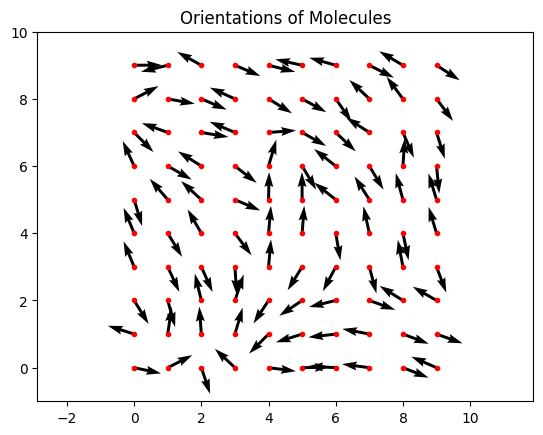

In [60]:
#test field to check the result
X, Y = np.meshgrid(np.arange(N), np.arange(N))
u_x = np.cos(theta)
u_y = np.sin(theta)
# Plot as Vectorfeld
plt.figure()
plt.quiver(X, Y, u_x, u_y)
plt.plot(X,Y,'r.')
plt.title("Orientations of Molecules")
plt.axis("equal")
plt.xlim(-1, N)
plt.ylim(-1, N)
plt.show()

### (c)

In order to extract meaningful results, run the Monte Carlo algorithm for a number of equilibration steps before starting the production run used for generating a sample.

After the equilibration, the system should have converged to a stable configuration. To check for convergence, calculate the interaction energy of the entire grid and plot the result as a function of Monte Carlo steps.

Determine the number of necessary equilibration steps by eye.

In [61]:
#1c Functions
#metropolis sweep (Montecarlosimulation)
def metropolis_sweep(theta, T, eps=1.0):
    N = theta.shape[0]
    accepted = 0
    for steps in range(N * N):
        i = np.random.randint(0,N)
        j = np.random.randint(0,N)
        #remember old theta
        theta_old = theta[i,j]
        #random rotation
        theta_new = np.random.rand()*2*np.pi 
        #calca old local energy
        E_loc_old = calc_E_loc(theta,i,j, eps= 1.0)
        #calc new local energy 
        theta[i,j] = theta_new
        E_loc_new = calc_E_loc(theta,i,j, eps= 1.0)
        delta_E = E_loc_new - E_loc_old
        if (delta_E > 0) and (np.random.rand() > np.exp(-delta_E/T)):
            theta[i, j] = theta_old
    return theta

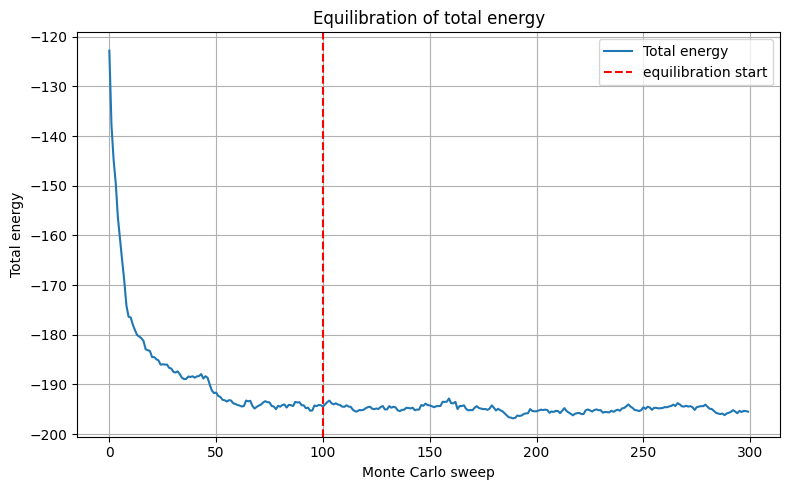

In [62]:
#1c
N = 10
eps = 1.0
T = 0.1
N_sweeps = 300
np.random.seed(10)

# new random starting angles
theta = 2 * np.pi * np.random.rand(N, N)

# Liste für die Gesamtenergie nach jedem Sweep
E_hist = np.empty(N_sweeps)
#print(theta.shape[0])
for sweep in range(N_sweeps):
    # one sweep -> N*N steps (1 times for every gridpoint)
    theta = metropolis_sweep(theta, T, eps=1.0)
    # Gesamtenergie nach jedem Sweep speichern
    E_hist[sweep] = calc_E_tot_l(theta, eps=eps)

# gewählter Equilibrium-Beginn, z. B. aus dem Plot abgelesen
eq_sweep = 100

plt.figure(figsize=(8, 5))
plt.plot(E_hist, lw=1.5, label="Total energy")
plt.axvline(eq_sweep, linestyle="--",color="red" ,lw=1.5,
            label=f"equilibration start")

plt.xlabel("Monte Carlo sweep")
plt.ylabel("Total energy")
plt.title("Equilibration of total energy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Order parameter

The elements of the two-dimensional nematic order tensor are defined as

$
Q_{\alpha\beta} = \frac{1}{N} \sum_{i=1}^{N} \left( 2 u_{\alpha}^{(i)} u_{\beta}^{(i)} - \delta_{\alpha\beta} \right),
$

where $N$ is the number of molecules, $u_{\alpha}^{(i)}\) and (\u_{\beta}^{(i)}\$ are the components of the orientation vector of molecule \(i\), and \(\delta_{\alpha\beta}\) is the Kronecker delta.

The largest eigenvalue of this tensor corresponds to the nematic order parameter \(S\), which can also be written as

$
S = \frac{1}{N} \sum_{i=1}^{N} \left( 2\cos^2\psi_i - 1 \right),
$

where \(\psi_i\) is the angle between the orientation of molecule \(i\) and the generally unknown nematic director.

From this expression, it follows that \(S \to 1\) when all molecules are perfectly aligned with the director. In contrast, \(S \to 0\) in the isotropic phase, where the molecular orientations are randomly distributed.

## (a)

Write a script to calculate the tensor $Q$ and the order parameter $S$ at every Monte Carlo step from Eq. (2).  
Calculate the distribution of the order parameter $S$ over a large number of Monte Carlo steps.  
Plot the corresponding histogram both for a temperature $k_B T \ll \varepsilon$ and for a temperature $k_B T \gg \varepsilon$.  
Add error bars to the plots according to the Bayesian approach with a flat prior.

In [63]:
#2a functions
# determine Q and S
def determine_Q_S(theta):
    N = theta.size
    # x and y component of U 
    u_x = np.cos(theta)
    u_y = np.sin(theta)

    # calc Q_ij as given in formula 2 
    Q_xx  = np.sum(2*u_x*u_x - 1) / N
    Q_yy  = np.sum(2*u_y*u_y - 1) / N
    # Q_xy = Q_yx
    Q_xy = np.sum(2*u_x*u_y) / N

    # Built the matrix
    Q = np.matrix([[Q_xx,Q_xy],
                  [Q_xy,Q_yy]])
    
    #calc eigenvalues of Q 
    ev = np.linalg.eigvals(Q)
    #get the largest eingenvale for S 
    S = np.max(ev)

    return Q,S

#Q_test, S_test = determine_Q_S(theta)
#print("Q =")
#print(Q_test)
#print("S =", S_test)

Last Q:
[[-0.93624849 -0.24224584]
 [-0.24224584  0.93624849]]
Last S: 0.967080288074543


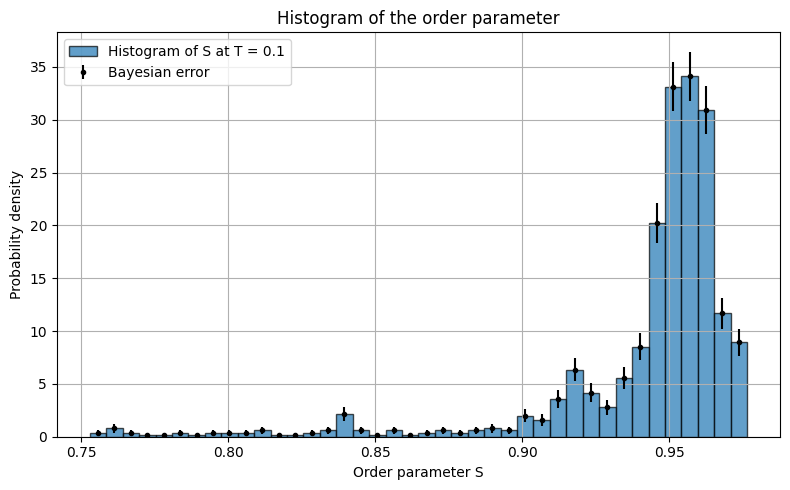

Last Q:
[[ 0.07116925 -0.12284249]
 [-0.12284249 -0.07116925]]
Last S: 0.14196950633905364


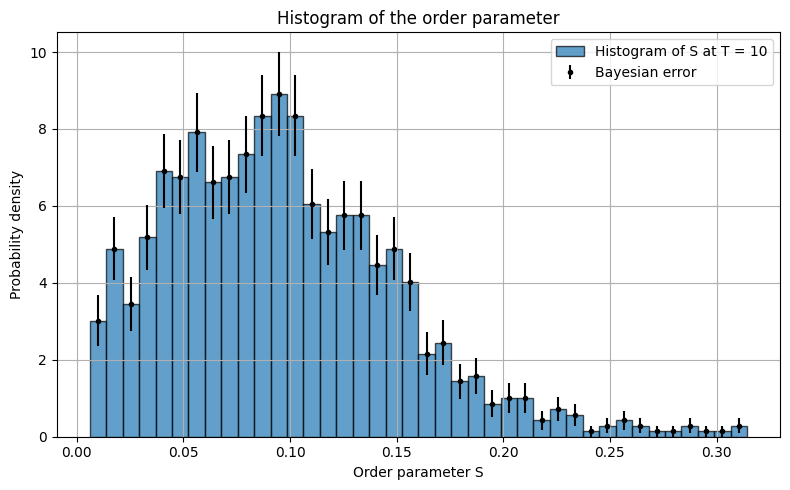

In [64]:
# 2a
N = 10
eps = 1.0
T = [0.1,10]
N_sweeps_to_eq = 100
N_sweeps = 900
np.random.seed(42)

# for all Temperatures of the array T
for temps in range(len(T)):
    # new random starting angles
    theta = 2 * np.pi * np.random.rand(N, N)
    # array for S values
    S_hist = np.empty(N_sweeps)

    # Monte Carlo simulation with sweeps
    for sweep in range(N_sweeps_to_eq + N_sweeps):

        # one sweep -> N*N steps (1 times for every gridpoint)
        theta = metropolis_sweep(theta, T[temps], eps=1.0)

        # collect S after equlibriation
        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # print values to check
    print("Last Q:")
    print(Q)
    print("Last S:", S)

    # histogram of S
    N_bins = 40
    counts, edges = np.histogram(S_hist, bins=N_bins, density=False)

    bin_width = edges[1] - edges[0]
    centers = 0.5 * (edges[:-1] + edges[1:])

    numberOfSamples = len(S_hist)

    # Bayesian expectation value and error for pdf with flat prior
    expectationValue = (counts + 1) / ((numberOfSamples + 2) * bin_width)
    error = np.sqrt((counts + 1) * (numberOfSamples - counts + 1) /
                    ((numberOfSamples + 2)**2 * (numberOfSamples + 3))) / bin_width

    plt.figure(figsize=(8, 5))
    plt.bar(centers, expectationValue, width=bin_width, alpha=0.7, edgecolor="black",
            label=f"Histogram of S at T = {T[temps]}")
    plt.errorbar(centers, expectationValue, yerr=error, fmt="o", markersize=3,
                color="black", label="Bayesian error")

    plt.xlabel("Order parameter S")
    plt.ylabel("Probability density")
    plt.title("Histogram of the order parameter")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

(b) For both temperatures, calculate and plot the autocorrelation function of \(S\) as a function of the number of Monte Carlo steps. Calculate the integrated autocorrelation time \(\tau_{\mathrm{int}}\). Check your estimate of the autocorrelation time by assuming an exponential decay of the autocorrelation function and plotting your data together with the exponential decay.

In [65]:
#2b functions
# Autocorrelation of S
def autocorrelation_lag(S, lag):
    N_samples = len(S)

    previousValues = S[:N_samples - lag]
    followingValues = S[lag:]

    meanAll = np.mean(S)

    numerator = np.sum((previousValues - meanAll) * (followingValues - meanAll))
    denominator = np.sum((S - meanAll)**2)

    return numerator / denominator


# alternative empirical definition
def autocorrelation_lag_1(S, lag):
    N_samples = len(S)

    previousValues = S[:N_samples - lag]
    followingValues = S[lag:]

    meanPrevVals = np.mean(previousValues)
    meanFollVals = np.mean(followingValues)

    numerator = np.sum((previousValues - meanPrevVals) * (followingValues - meanFollVals))
    denominator = np.sqrt(np.sum((previousValues - meanPrevVals)**2) *
                          np.sum((followingValues - meanFollVals)**2))

    return numerator / denominator

# autocorrelation function 
def autocorrelation_function(S, maxLag=None):
    N_samples = len(S)

    if maxLag is None:
        maxLag = N_samples - 1

    acf = np.empty(maxLag + 1)

    for lag in range(maxLag + 1):
        acf[lag] = autocorrelation_lag(S, lag)

    return acf

# integrate autocorrelationtime
def integrated_autocorrelation_time(acf):
    tau_int = 0.5

    for lag in range(1, len(acf)):
        if acf[lag] < 0:
            break
        tau_int += acf[lag]

    return tau_int


def plot_autocorrelation(acf, tau_int, temperature):
    lags = np.arange(len(acf))
    exp_decay = np.exp(-lags / tau_int)

    plt.figure(figsize=(8, 5))
    plt.plot(lags, acf, lw=1.5, label="Autocorrelation function")
    plt.plot(lags, exp_decay, "--", lw=1.5,
             label=rf"$e^{{-t/\tau_{{int}}}}$, $\tau_{{int}} = {tau_int:.2f}$")

    plt.xlabel("Lag / Monte Carlo sweep")
    plt.ylabel("Autocorrelation")
    plt.title(f"Autocorrelation of S at T = {temperature}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

T = 0.1
tau_int = 43.0846


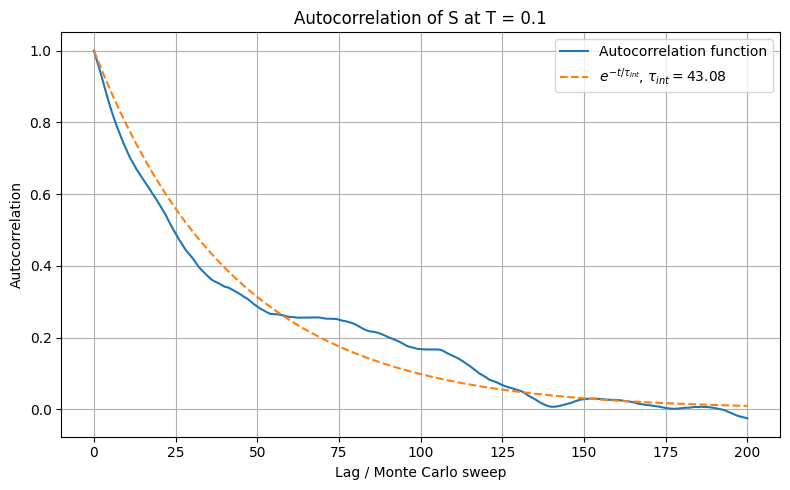

T = 10.0
tau_int = 0.7284


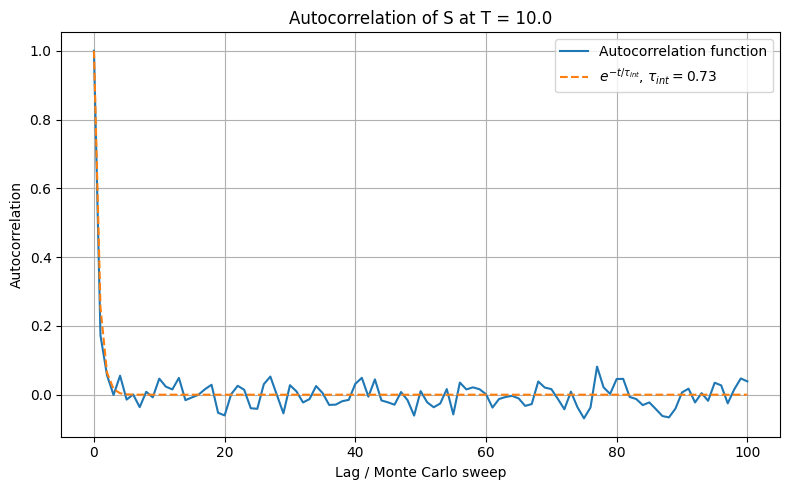

In [66]:
#2b
T = [0.1, 10.0]
N_sweeps_to_eq = 100
N_sweeps = 900
np.random.seed(42)

# for all Temperatures of T
for temps in range(len(T)):
    theta = 2 * np.pi * np.random.rand(N, N)

    S_hist = np.empty(N_sweeps)

    for sweep in range(N_sweeps_to_eq + N_sweeps):
        # one sweep -> N*N steps (1 times for every gridpoint)
        theta = metropolis_sweep(theta, T[temps], eps=1.0)

        # calc Q and S if equlibriated
        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # choose max lag (different for the temperatures)
    if T[temps] == 0.1:
        maxLag = 200
    else:
        maxLag = 100

    acf = autocorrelation_function(S_hist, maxLag=maxLag)
    tau_int = integrated_autocorrelation_time(acf)

    print(f"T = {T[temps]}")
    print(f"tau_int = {tau_int:.4f}")

    plot_autocorrelation(acf, tau_int, T[temps])

### 3. Phase transition

#### (a)
At a low temperature, $k_B T \ll \varepsilon$, the liquid crystal is in the nematic phase. Starting at low temperature, slowly increase the temperature and plot the average order parameter $\langle S \rangle$ as a function of the temperature.

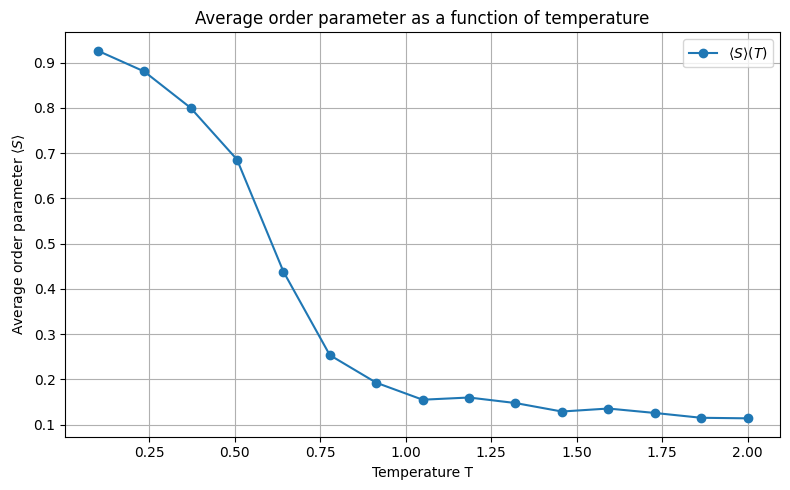

In [67]:
# 3a) 
N = 10
eps = 1.0
N_sweeps_to_eq = 100
N_sweeps = 300
np.random.seed(42)

# temperatures
T = np.linspace(0.1, 2.0, 15)

# arrays for results
S_mean_values = np.empty(len(T))

for temps in range(len(T)):
    #T = T[temps]

    # new random starting angles
    theta = 2 * np.pi * np.random.rand(N, N)

    # list for S values after equilibration
    S_hist = np.empty(N_sweeps)

    # Monte Carlo simulation
    for sweep in range(N_sweeps_to_eq + N_sweeps):
        # one sweep -> N*N steps (1 times for every gridpoint)
        theta = metropolis_sweep(theta, T[temps], eps=1.0)

        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # average order parameter
    S_mean_values[temps] = np.mean(S_hist)

# plot
plt.figure(figsize=(8, 5))
plt.plot(T, S_mean_values, "o-", label=r"$\langle S \rangle (T)$")
plt.xlabel("Temperature T")
plt.ylabel(r"Average order parameter $\langle S \rangle$")
plt.title(r"Average order parameter as a function of temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

(b) Calculate the standard deviation of the order parameter using your code to cal-
culate τint from part 2b to make sure that the data used for the estimate are
independent and uncorrelated. Plot the order parameter as a function of the
temperature including error bars.

T = 0.100, <S> = 0.9265, std = 0.0417, tau_int = 32.8727, N_eff = 4.56
T = 0.236, <S> = 0.8807, std = 0.0334, tau_int = 30.7580, N_eff = 4.88
T = 0.371, <S> = 0.8003, std = 0.0461, tau_int = 9.4798, N_eff = 15.82
T = 0.507, <S> = 0.6860, std = 0.0682, tau_int = 8.3340, N_eff = 18.00
T = 0.643, <S> = 0.4384, std = 0.1452, tau_int = 18.3962, N_eff = 8.15
T = 0.779, <S> = 0.2537, std = 0.1214, tau_int = 6.1344, N_eff = 24.45
T = 0.914, <S> = 0.1927, std = 0.0939, tau_int = 3.9439, N_eff = 38.03
T = 1.050, <S> = 0.1551, std = 0.0750, tau_int = 1.7220, N_eff = 87.11
T = 1.186, <S> = 0.1600, std = 0.0905, tau_int = 2.9418, N_eff = 50.99
T = 1.321, <S> = 0.1478, std = 0.0767, tau_int = 1.9394, N_eff = 77.34
T = 1.457, <S> = 0.1290, std = 0.0604, tau_int = 1.2666, N_eff = 118.43
T = 1.593, <S> = 0.1356, std = 0.0686, tau_int = 1.4627, N_eff = 102.55
T = 1.729, <S> = 0.1259, std = 0.0658, tau_int = 1.5931, N_eff = 94.15
T = 1.864, <S> = 0.1152, std = 0.0593, tau_int = 1.0036, N_eff = 149.46
T =

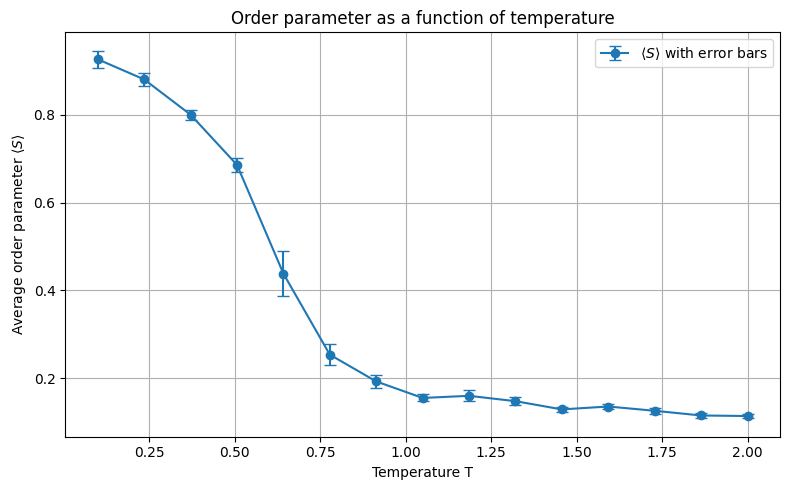

In [68]:
# 3b) 
N = 10
eps = 1.0
N_sweeps_to_eq = 100
N_sweeps = 300
np.random.seed(42)

# temperatures
T = np.linspace(0.1, 2.0, 15)

# arrays for results
S_mean_values = np.empty(len(T))
S_std_values = np.empty(len(T))
S_error_values = np.empty(len(T))
tau_int_values = np.empty(len(T))

for temps in range(len(T)):
    
    # new random starting angles
    theta = 2 * np.pi * np.random.rand(N, N)

    # list for S values after equilibration
    S_hist = np.empty(N_sweeps)

    # Monte Carlo simulation
    for sweep in range(N_sweeps_to_eq + N_sweeps):
        # one sweep -> N*N steps (1 times for every gridpoint)
        theta = metropolis_sweep(theta, T[temps], eps=1.0)

        if sweep >= N_sweeps_to_eq:
            Q, S = determine_Q_S(theta)
            S_hist[sweep - N_sweeps_to_eq] = S

    # mean S
    S_mean = np.mean(S_hist)

    # autocorrelation and tau_int
    acf = autocorrelation_function(S_hist, maxLag=min(200, len(S_hist)-1))
    tau_int = integrated_autocorrelation_time(acf)

    # standard deviation of S
    S_std = np.std(S_hist, ddof=1)

    # effective number of independent samples
    N_eff = len(S_hist) / (2.0 * tau_int)

    # error of the mean
    S_error = S_std / np.sqrt(N_eff)

    # store values
    S_mean_values[temps] = S_mean
    S_std_values[temps] = S_std
    S_error_values[temps] = S_error
    tau_int_values[temps] = tau_int

    print(f"T = {T[temps]:.3f}, <S> = {S_mean:.4f}, std = {S_std:.4f}, tau_int = {tau_int:.4f}, N_eff = {N_eff:.2f}")

# plot
plt.figure(figsize=(8, 5))
plt.errorbar(T, S_mean_values, yerr=S_error_values, fmt="o-", capsize=4,
             label=r"$\langle S \rangle$ with error bars")
plt.xlabel("Temperature T")
plt.ylabel(r"Average order parameter $\langle S \rangle$")
plt.title(r"Order parameter as a function of temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### (c)
At what temperature does the phase transition take place? What happens to the standard deviation of the order parameter near the phase transition? What is the order of the phase transition?

Estimated transition temperature: T_c ≈ 0.643
Maximum standard deviation: sigma_S ≈ 0.1452


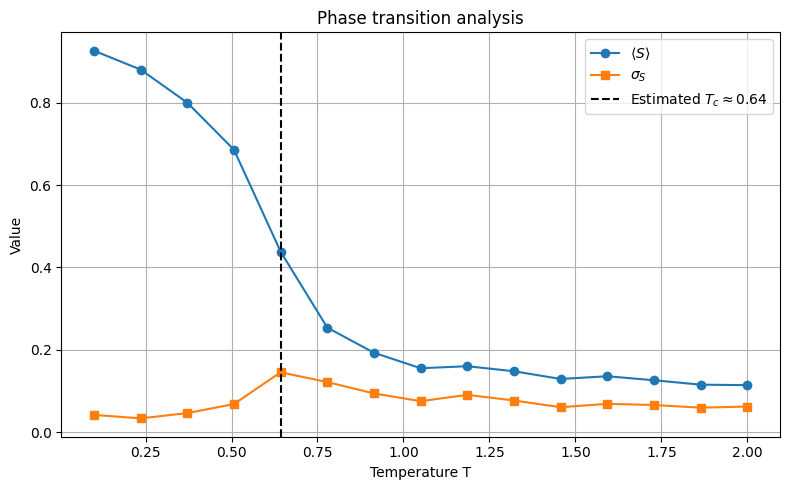

In [69]:
# 3c) 

# transition temperature at max of standartdiviation of s
idx_max_std = np.argmax(S_std_values)
T_transition = T[idx_max_std]

print(f"Estimated transition temperature: T_c ≈ {T_transition:.3f}")
print(f"Maximum standard deviation: sigma_S ≈ {S_std_values[idx_max_std]:.4f}")

# plot mean S and standard deviation
plt.figure(figsize=(8, 5))
plt.plot(T, S_mean_values, "o-", label=r"$\langle S \rangle$")
plt.plot(T, S_std_values, "s-", label=r"$\sigma_S$")
plt.axvline(T_transition, linestyle="--", color="black",
            label=rf"Estimated $T_c \approx {T_transition:.2f}$")

plt.xlabel("Temperature T")
plt.ylabel("Value")
plt.title("Phase transition analysis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()